# Линейная регрессия

### Работа с признаками 

Датасет https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv 


Признаки:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж 
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного


Целевая паременная:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

In [13]:
!curl -o dataset.csv  https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv    

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 4463k    0 39810    0     0  48260      0  0:01:34 --:--:--  0:01:34 48371
 92 4463k   92 4133k    0     0  2261k      0  0:00:01  0:00:01 --:--:-- 2263k
100 4463k  100 4463k    0     0  2425k      0  0:00:01  0:00:01 --:--:-- 2428k


In [14]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Предварительный анализ данных

In [15]:
df = pd.read_csv("dataset.csv")
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [16]:
df.shape

(63326, 11)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [18]:
df.isnull().sum()

Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64

In [19]:
# категориальные данные

cat_features_mask = (df.dtypes == "object").values
cat_columns = df.columns[cat_features_mask]
df_cat = df[cat_columns]
df_cat.head()

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Destination,Gender
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,MALAYSIA,F
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,MALAYSIA,F
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,AUSTRALIA,NaN
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,AUSTRALIA,NaN
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,ITALY,NaN


In [20]:
# числовые данные

num_features_mask = ~cat_features_mask
df_num = df[df.columns[num_features_mask]]
df_num.head()

,Duration,Net Sales,Commision (in value),Age
0,186,-29.0,9.57,81
1,186,-29.0,9.57,71
2,65,-49.5,29.70,32
3,60,-39.6,23.76,32
4,79,-19.8,11.88,41


## Обработка данных

- Обработка пропущенных значений
- Преобразование категориальных переменных
- Мастабированние данных

In [21]:
def minmax_scale(X: np.ndarray) -> np.ndarray:
    X_min: np.ndarray = np.min(X, axis=0)
    X_max: np.ndarray = np.max(X, axis=0)

    range_vals: np.ndarray = X_max - X_min
    range_vals[range_vals == 0] = 1 

    X_scaled = (X - X_min) / range_vals

    return X_scaled


def apply_minmax_scale(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    X = df[column_name].to_numpy().reshape(-1, 1)
    scaled_data = minmax_scale(X).flatten()  # Возвращаем обратно в 1D  
    df[f"{column_name}_scaled"] = scaled_data

    return df


def onehot_encoding(X: np.ndarray) -> np.ndarray:
    unique_vals, idx = np.unique(X, return_inverse=True)
    Z: np.ndarray = np.zeros((len(X), len(unique_vals)), dtype=int)
    Z[np.arange(len(X)), idx] = 1

    return Z


def apply_onehot_encoding(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    X = df[column_name].to_numpy()
    encoded_data = onehot_encoding(X)

    unique_vals = np.unique(X)
    encoded_columns = [f"{column_name}_{val}" for val in unique_vals]

    encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns,  index=df.index)
    df = df.join(encoded_df)

    return df


def label_encoding(X: np.ndarray) -> np.ndarray:
    unique_vals, idx = np.unique(X, return_inverse=True)

    return idx


def apply_label_encoding(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    X = df[column_name].to_numpy()
    encoded_data = label_encoding(X)

    df[f'{column_name}_encoded'] = encoded_data

    return df
    

### Обработка Gender

В столбце 'Gender' более половины значений отсутствует. Если он не важен для предсказания 'Claim', можно удалить. При равномерном распределении классов можно заполнить случайными "F" или "M"

Проверим распределение признака 'Gender' и зависимость таргета от 'Gender'

C:\Users\matve\AppData\Local\Temp\ipykernel_52904\3642284929.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Gender'], palette='pastel')


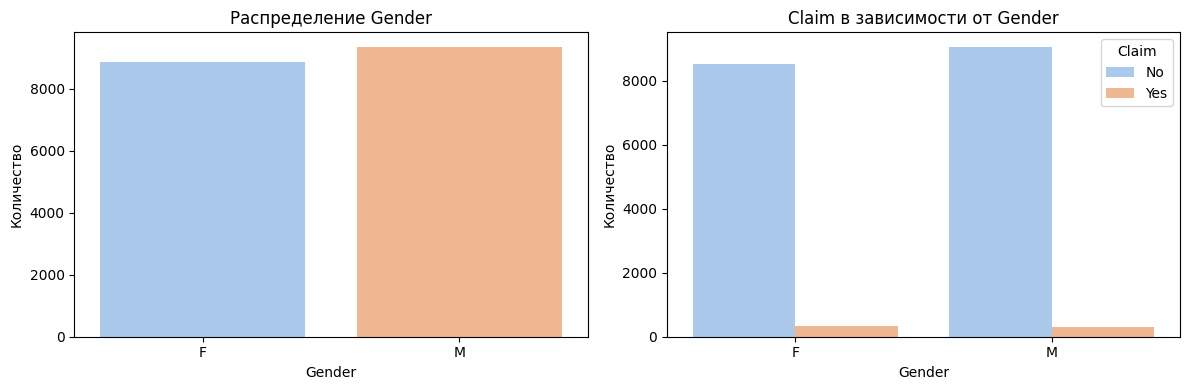

In [22]:
plt.figure(figsize=(12, 4))  

plt.subplot(1, 2, 1)  
sns.countplot(x=df['Gender'], palette='pastel')
plt.title("Распределение Gender")
plt.xlabel("Gender")
plt.ylabel("Количество")

plt.subplot(1, 2, 2) 
sns.countplot(x='Gender', hue='Claim', data=df, palette='pastel')
plt.title("Claim в зависимости от Gender")
plt.xlabel("Gender")
plt.ylabel("Количество")
plt.legend(title="Claim")

plt.tight_layout() 
plt.show()

In [23]:
pd.crosstab(df['Gender'], df['Claim'], normalize='index') * 100


Claim,No,Yes
Gender,,
F,96.100090,3.899910
M,96.865304,3.134696


Анализ показал приблизительно равное распределение, поэтому выбрано случайное заполнение.

In [24]:
df['Gender'] = df['Gender'].apply(lambda x: np.random.choice(df['Gender'].dropna()) if pd.isna(x) else x)

C:\Users\matve\AppData\Local\Temp\ipykernel_52904\2693360469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Gender'], palette='pastel')


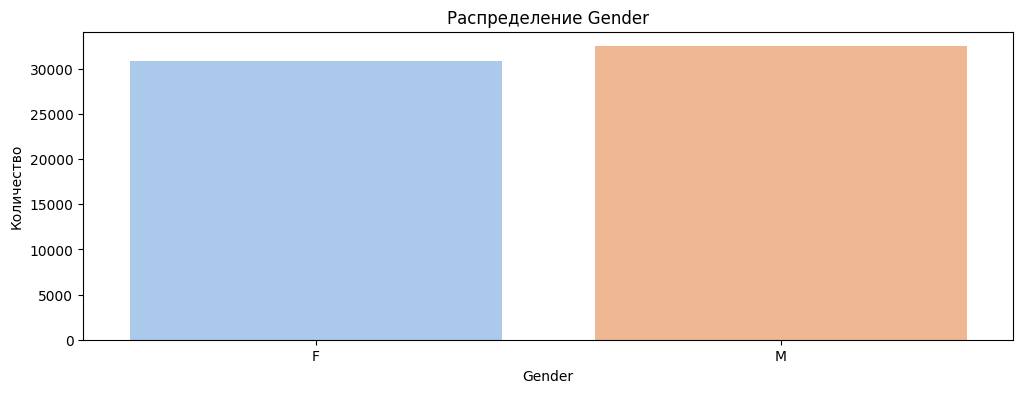

In [25]:
plt.figure(figsize=(12, 4))  

sns.countplot(x=df['Gender'], palette='pastel')
plt.title("Распределение Gender")
plt.xlabel("Gender")
plt.ylabel("Количество")

plt.show()

### Анализ каналов продаж и типа агенства

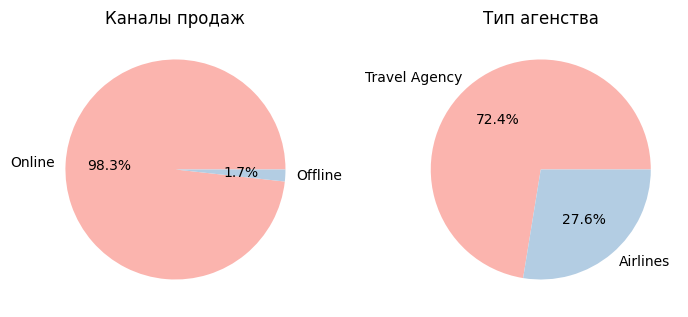

In [26]:
plt.figure(figsize=(20, 6))  

plt.subplot(1, 2, 1)  
df['Distribution Channel'].value_counts().plot(kind='pie', label='', autopct='%1.1f%%', figsize=(7, 7), colors=plt.cm.Pastel1.colors)
plt.title('Каналы продаж')

plt.subplot(1, 2, 2) 
df['Agency Type'].value_counts().plot(kind='pie', label='', autopct='%1.1f%%', figsize=(7, 7), colors=plt.cm.Pastel1.colors)
plt.title('Тип агенства')

plt.tight_layout()  
plt.show()

Пропуски в данных отсутствуют.
Для кодирования признаков применён one-hot encoding.

### Анализ длительности поездки

In [27]:
df_num['Duration'].describe()

count    63326.000000
mean        49.317074
std        101.791566
min         -2.000000
25%          9.000000
50%         22.000000
75%         53.000000
max       4881.000000
Name: Duration, dtype: float64

Максимальное значение длительности поездки существенно квартиль превышает 75% и среднее, что указывает на возможные выбросы.

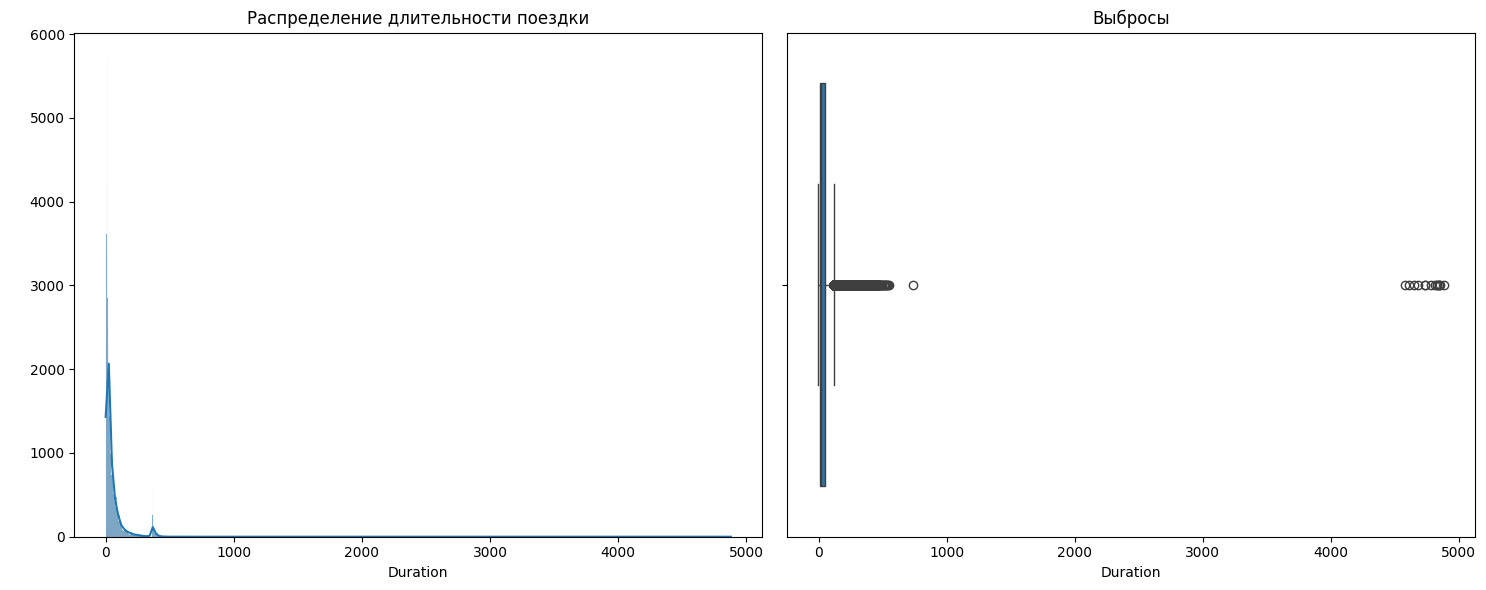

In [28]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Duration'], kde=True)
plt.title('Распределение длительности поездки')
plt.xlabel('Duration')
plt.ylabel(' ')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Duration'])
plt.title('Выбросы')

plt.tight_layout()  
plt.show()

Гистограмма и боксплот подтверждают аномалии: данные концентрируются в диапазоне 4000–5000 дней. Это может быть единичной поездкой, но более вероятно — выброс. Принимаем гипотезу о выбросе.

In [29]:
df['Duration'] = df['Duration'].apply(lambda x: x if x <= 700 else None)

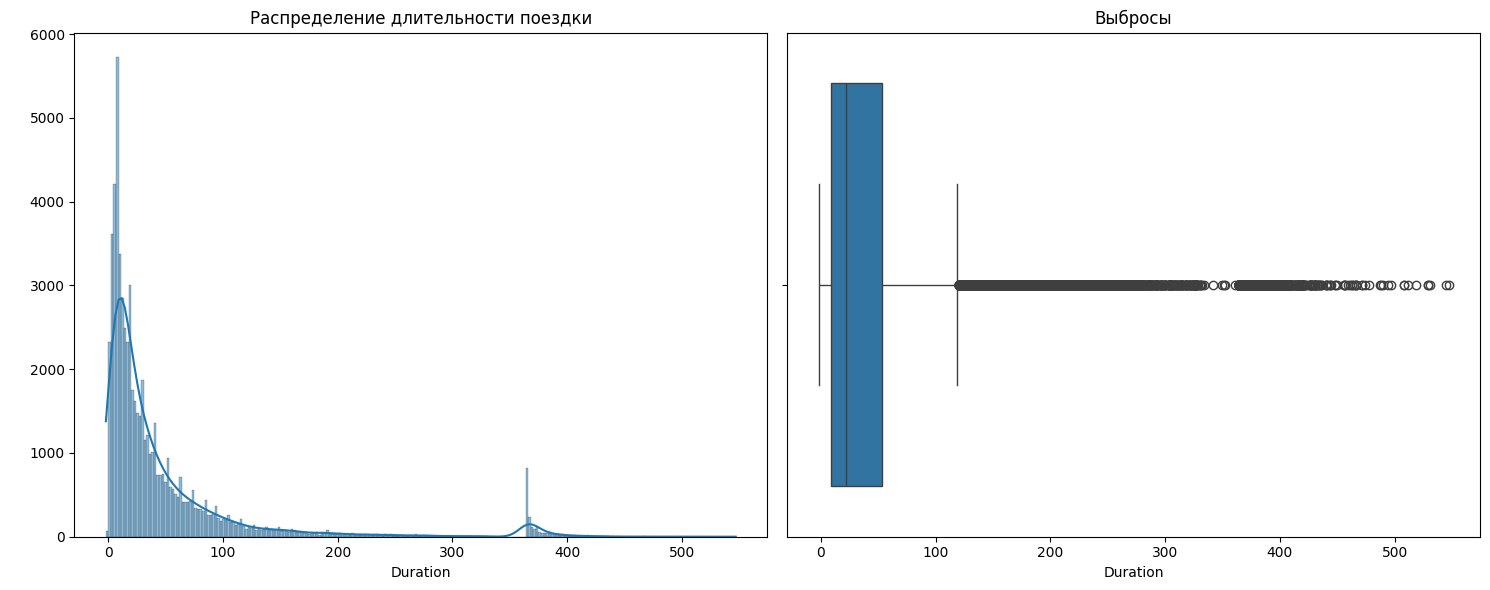

In [30]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Duration'], kde=True)
plt.title('Распределение длительности поездки')
plt.xlabel('Duration')
plt.ylabel(' ')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Duration'])
plt.title('Выбросы')

plt.tight_layout()  
plt.show()

### Обработка места назначения



In [31]:
df['Destination'].describe()

count         63326
unique          149
top       SINGAPORE
freq          13255
Name: Destination, dtype: object

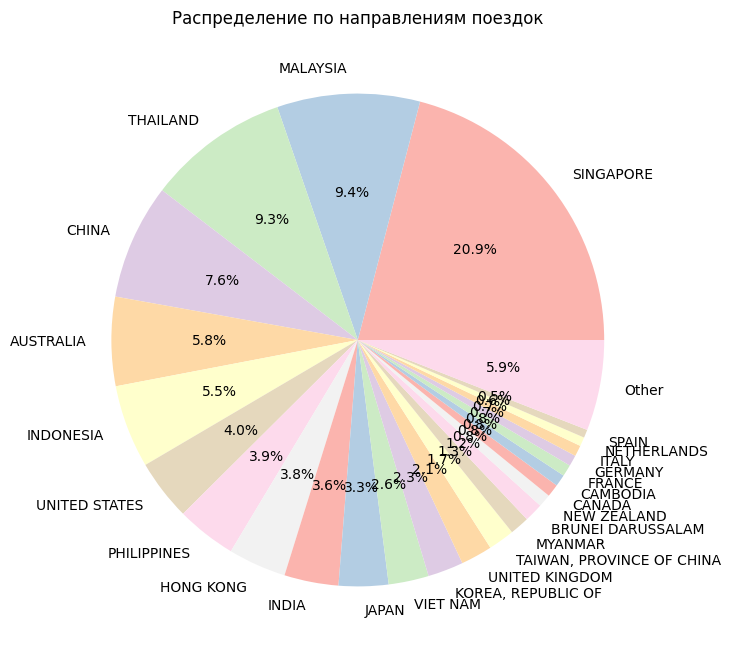

In [32]:
top_n = 25
top_countries = df['Destination'].value_counts().head(top_n)

other_countries_count = df['Destination'].value_counts().iloc[top_n:].sum()
top_countries['Other'] = other_countries_count

plt.figure(figsize=(8, 8))
top_countries.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
plt.title('Распределение по направлениям поездок')
plt.ylabel('') 
plt.show()


Датасет содержит 149 уникальных мест назначения, что делает one-hot-encoding неэффективным из-за создания разреженной матрицы, ведущей к ошибкам в линейной регрессии.

Применяем частотное кодирование: каждое место назначения заменяется количеством его появлений в данных. Это сохраняет информацию о популярности направлений без увеличения размерности признаков.

In [33]:
destination_freq = df['Destination'].value_counts()
df['Destination_frequency'] = df['Destination'].map(destination_freq)

In [34]:
df['Destination_frequency'].describe()

count    63326.000000
mean      5261.861921
std       4477.942926
min          1.000000
25%       2061.000000
50%       3694.000000
75%       5930.000000
max      13255.000000
Name: Destination_frequency, dtype: float64

C:\Users\matve\AppData\Local\Temp\ipykernel_52904\3673291752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Destination_frequency'], palette='pastel')


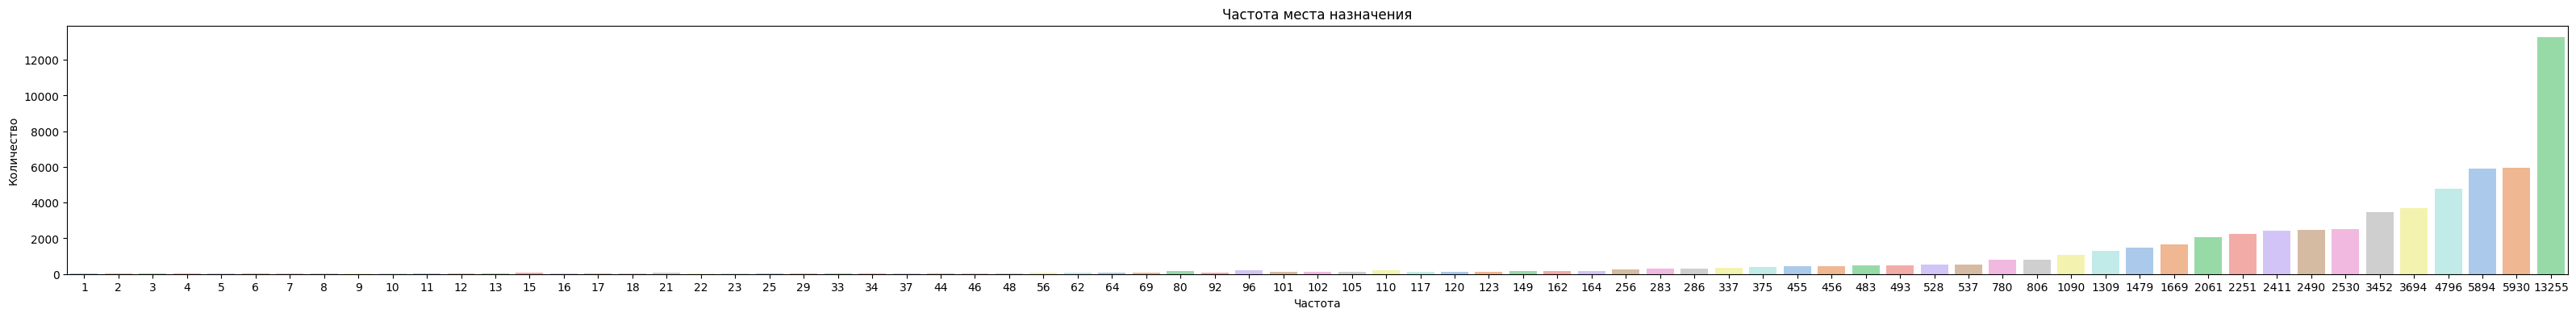

In [35]:
plt.figure(figsize=(40, 4))  

sns.countplot(x=df['Destination_frequency'], palette='pastel')
plt.title("Частота места назначения")
plt.xlabel("Частота")
plt.ylabel("Количество")

plt.show()

### Обработка категориальных данных

In [36]:
df['Product Name'].describe()

count                 63326
unique                   26
top       Cancellation Plan
freq                  18630
Name: Product Name, dtype: object

In [37]:
df['Agency'].describe()

count     63326
unique       16
top         EPX
freq      35119
Name: Agency, dtype: object

Признаки "Agency" и "Product Name" не имеют порядка, поэтому применён label encoding для преобразования категорий в числа.

In [38]:
df_encoded = apply_label_encoding(df, 'Agency')
df_encoded = apply_label_encoding(df, 'Product Name')

Признаки "Agency Type", "Distribution Channel", "Gender" имеют по две категории, к ним применён one-hot encoding.

In [39]:
df_encoded = apply_onehot_encoding(df, 'Agency Type')

In [40]:
df_encoded = apply_onehot_encoding(df_encoded, 'Distribution Channel')

In [41]:
df_encoded = apply_onehot_encoding(df_encoded, 'Gender')

In [42]:
df_encoded["Claim"] = df_encoded["Claim"].map({"No": 0, "Yes": 1}).fillna(0).astype(int)


Исходные категориальные столбцы удалены.

In [43]:
columns_to_drop = [
    "Agency", "Agency Type", "Distribution Channel", "Product Name", "Destination", "Gender"
]
df_encoded.drop(columns=columns_to_drop, errors="ignore", inplace=True)


In [44]:
df_encoded.head()

,Claim,Duration,Net Sales,Commision (in value),Age,Destination_frequency,Agency_encoded,Product Name_encoded,Agency Type_Airlines,Agency Type_Travel Agency,Distribution Channel_Offline,Distribution Channel_Online,Gender_F,Gender_M
0,0,186.0,-29.0,9.57,81,5930,3,12,0,1,1,0,1,0
1,0,186.0,-29.0,9.57,71,5930,3,12,0,1,1,0,1,0
2,0,65.0,-49.5,29.70,32,3694,6,16,0,1,0,1,1,0
3,0,60.0,-39.6,23.76,32,3694,6,16,0,1,0,1,0,1
4,0,79.0,-19.8,11.88,41,455,6,16,0,1,0,1,1,0


### Анализ данных продаж

In [45]:
df_num.head()

,Duration,Net Sales,Commision (in value),Age
0,186,-29.0,9.57,81
1,186,-29.0,9.57,71
2,65,-49.5,29.70,32
3,60,-39.6,23.76,32
4,79,-19.8,11.88,41


In [46]:
df_encoded['Net Sales'].describe()

count    63326.000000
mean        40.702018
std         48.845637
min       -389.000000
25%         18.000000
50%         26.530000
75%         48.000000
max        810.000000
Name: Net Sales, dtype: float64

Отрицательные значения в "Net Sales" выглядят как аномалия или задолженность.

In [47]:
negative_sales = df_encoded[df_encoded['Net Sales'] < 0]
negative_sales.shape[0]

678

Проверка показала 678 записей с отрицательными продажами (1% от 60 000).
Решение: удалить эти записи.

In [48]:
df = df_encoded[df_encoded['Net Sales'] >= 0]

### Масштабирование числовых данных

In [49]:
df_scaled = apply_minmax_scale(df_encoded, 'Net Sales')

In [50]:
# df_scaled = apply_minmax_scale(df_encoded, 'Duration')

In [51]:
df_scaled = apply_minmax_scale(df_encoded, 'Commision (in value)')

In [52]:
df_scaled = apply_minmax_scale(df_encoded, 'Age')

Числовые признаки масштабированы с помощью MinMaxScaler.
Исходные столбцы удалены.

In [53]:
columns_to_drop = ["Duration", "Net Sales", "Commision (in value)", "Age", "Destination_frequency"]
df_scaled = df_scaled.drop(columns=columns_to_drop, errors="ignore")

### Итоговый датасет

In [54]:
df_scaled.head()

,Claim,Agency_encoded,Product Name_encoded,Agency Type_Airlines,Agency Type_Travel Agency,Distribution Channel_Offline,Distribution Channel_Online,Gender_F,Gender_M,Net Sales_scaled,Commision (in value)_scaled,Age_scaled
0,0,3,12,0,1,1,0,1,0,0.300250,0.033757,0.686441
1,0,3,12,0,1,1,0,1,0,0.300250,0.033757,0.601695
2,0,6,16,0,1,0,1,1,0,0.283153,0.104762,0.271186
3,0,6,16,0,1,0,1,0,1,0.291410,0.083810,0.271186
4,0,6,16,0,1,0,1,1,0,0.307923,0.041905,0.347458


### Вывод 

#### Анализ данных
Проверили данные на распределение, пропуски и ошибки. Нашли аномалии, например, отрицательные значения в "Net Sales".

#### Предобработка данных
Категориальные признаки обработали: для малого числа категорий применили one-hot encoding, для многозначных использовали label encoding. Числовые признаки масштабировали через MinMaxScaler, чтобы устранить дисбаланс.